## check the blur effect

## check 5 images for blurring / dimension using gausian filter produce 3 sets of images( 5 each) and get the variance,mean,gm 
## 1. make changes in the image for blurring on 3 sets
## 2. send those images to craft.py and get the coords and confidence
## 3. get the mean,gm,variance on all the 3 batches

In [12]:
# Step 1: Import required libraries
import cv2
import numpy as np
import os
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
from scipy import stats
import glob

# Set up paths
base_path = Path("/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft")
images_path = base_path / "images"
output_base = base_path / "blurred_images"

print(f"Base path: {base_path}")
print(f"Images path: {images_path}")
print(f"Output base: {output_base}")

# List all PNG images
image_files = list(images_path.glob("*.png"))
print(f"\nFound {len(image_files)} images:")
for img_file in image_files:
    print(f"  - {img_file.name}")


Base path: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft
Images path: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft/images
Output base: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft/blurred_images

Found 5 images:
  - 01_10021040891039611111693747018_page_1.png
  - 11_100210067043036921111705241030_page_3.png
  - 05_10021030401065351171694351729_page_11.png
  - 07_100212788145098831111705212250_page_5.png
  - 02_10021039271083421101694954824_page_2.png


In [13]:
# Step 2: Create folder structure
def create_folder_structure(base_path):
    """Create organized folder structure for original and blurred images"""
    folders = {
        'original': base_path / 'original',
        'light_blur': base_path / 'light_blur', 
        'medium_blur': base_path / 'medium_blur',
        'heavy_blur': base_path / 'heavy_blur'
    }
    
    # Create directories
    for folder_name, folder_path in folders.items():
        folder_path.mkdir(parents=True, exist_ok=True)
        print(f"Created/verified folder: {folder_path}")
    
    return folders

# Create the folder structure
folders = create_folder_structure(output_base)

# Copy original images to original folder
print("\nCopying original images...")
for img_file in image_files:
    destination = folders['original'] / img_file.name
    shutil.copy2(img_file, destination)
    print(f"Copied: {img_file.name} -> original/")


Created/verified folder: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft/blurred_images/original
Created/verified folder: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft/blurred_images/light_blur
Created/verified folder: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft/blurred_images/medium_blur
Created/verified folder: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft/blurred_images/heavy_blur

Copying original images...
Copied: 01_10021040891039611111693747018_page_1.png -> original/
Copied: 11_100210067043036921111705241030_page_3.png -> original

In [14]:
# Step 3: Implement Gaussian Blur with OpenCV
def apply_gaussian_blur(image_path, sigma, output_path):
    """
    Apply Gaussian blur to an image using OpenCV
    
    Args:
        image_path: Path to input image
        sigma: Standard deviation for Gaussian kernel
        output_path: Path to save blurred image
    
    Returns:
        dict: Image statistics (variance, mean, geometric mean)
    """
    # Read image
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Could not read image: {image_path}")
    
    # Calculate kernel size (should be odd and roughly 6*sigma + 1)
    kernel_size = int(6 * sigma + 1)
    if kernel_size % 2 == 0:
        kernel_size += 1
    
    # Apply Gaussian blur
    blurred_img = cv2.GaussianBlur(img, (kernel_size, kernel_size), sigma)
    
    # Save blurred image
    cv2.imwrite(str(output_path), blurred_img)
    
    # Calculate image statistics on grayscale version
    gray_blurred = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2GRAY)
    
    # Calculate metrics
    variance = np.var(gray_blurred)
    mean = np.mean(gray_blurred)
    # Geometric mean (add small epsilon to avoid log(0))
    geometric_mean = stats.gmean(gray_blurred.flatten() + 1e-10)
    
    return {
        'variance': variance,
        'mean': mean,
        'geometric_mean': geometric_mean,
        'sigma': sigma,
        'kernel_size': kernel_size
    }

# Define blur parameters
blur_configs = {
    'light_blur': {'sigma': 1.5, 'folder': folders['light_blur']},
    'medium_blur': {'sigma': 4.0, 'folder': folders['medium_blur']}, 
    'heavy_blur': {'sigma': 8.0, 'folder': folders['heavy_blur']}
}

print("Blur configurations:")
for name, config in blur_configs.items():
    print(f"  {name}: σ = {config['sigma']}")


Blur configurations:
  light_blur: σ = 1.5
  medium_blur: σ = 4.0
  heavy_blur: σ = 8.0


In [15]:
# Step 4: Process all images with different blur levels
results = {}

print("Processing images with different blur levels...")
print("=" * 60)

for img_file in image_files:
    img_name = img_file.name
    print(f"\nProcessing: {img_name}")
    
    # Initialize results for this image
    results[img_name] = {}
    
    # Process original image statistics
    original_stats = apply_gaussian_blur(img_file, 0, folders['original'] / img_name)
    original_stats['sigma'] = 0  # Original has no blur
    results[img_name]['original'] = original_stats
    print(f"  Original - Variance: {original_stats['variance']:.2f}, Mean: {original_stats['mean']:.2f}")
    
    # Process each blur level
    for blur_name, config in blur_configs.items():
        output_path = config['folder'] / img_name
        
        try:
            # Apply blur and get statistics
            stats_data = apply_gaussian_blur(img_file, config['sigma'], output_path)
            results[img_name][blur_name] = stats_data
            
            print(f"  {blur_name:12} (σ={config['sigma']}) - Variance: {stats_data['variance']:.2f}, Mean: {stats_data['mean']:.2f}, GM: {stats_data['geometric_mean']:.2f}")
            
        except Exception as e:
            print(f"  ERROR processing {blur_name}: {e}")
            results[img_name][blur_name] = None

print("\n" + "=" * 60)
print("✅ All images processed successfully!")


Processing images with different blur levels...

Processing: 01_10021040891039611111693747018_page_1.png
  Original - Variance: 3175.62, Mean: 146.67
  light_blur   (σ=1.5) - Variance: 3048.19, Mean: 146.67, GM: 133.78
  medium_blur  (σ=4.0) - Variance: 2894.19, Mean: 146.67, GM: 134.79
  heavy_blur   (σ=8.0) - Variance: 2740.59, Mean: 146.66, GM: 135.71

Processing: 11_100210067043036921111705241030_page_3.png
  Original - Variance: 1327.08, Mean: 179.23
  light_blur   (σ=1.5) - Variance: 1271.07, Mean: 179.23, GM: 176.03
  medium_blur  (σ=4.0) - Variance: 1196.70, Mean: 179.24, GM: 176.34
  heavy_blur   (σ=8.0) - Variance: 1142.42, Mean: 179.24, GM: 176.51

Processing: 05_10021030401065351171694351729_page_11.png
  Original - Variance: 2043.68, Mean: 173.58
  light_blur   (σ=1.5) - Variance: 1907.69, Mean: 173.58, GM: 167.71
  medium_blur  (σ=4.0) - Variance: 1720.49, Mean: 173.58, GM: 168.58
  heavy_blur   (σ=8.0) - Variance: 1605.13, Mean: 173.58, GM: 169.00

Processing: 07_1002127

In [16]:
# Step 5: Analyze and visualize quality metrics
import pandas as pd

def create_summary_dataframe(results):
    """Create a comprehensive summary DataFrame from results"""
    summary_data = []
    
    for img_name, img_results in results.items():
        for blur_type, stats in img_results.items():
            if stats is not None:
                summary_data.append({
                    'image_name': img_name,
                    'blur_type': blur_type,
                    'sigma': stats['sigma'],
                    'variance': stats['variance'],
                    'mean': stats['mean'],
                    'geometric_mean': stats['geometric_mean']
                })
    
    return pd.DataFrame(summary_data)

# Create summary DataFrame
df_summary = create_summary_dataframe(results)
print("📊 Quality Metrics Summary:")
print("=" * 80)
print(df_summary.round(3))

# Calculate aggregate statistics by blur type
print("\n📈 Aggregate Statistics by Blur Level:")
print("=" * 50)
aggregate_stats = df_summary.groupby('blur_type').agg({
    'variance': ['mean', 'std'],
    'mean': ['mean', 'std'], 
    'geometric_mean': ['mean', 'std'],
    'sigma': 'first'
}).round(3)

print(aggregate_stats)


📊 Quality Metrics Summary:
                                      image_name    blur_type  sigma  \
0    01_10021040891039611111693747018_page_1.png     original    0.0   
1    01_10021040891039611111693747018_page_1.png   light_blur    1.5   
2    01_10021040891039611111693747018_page_1.png  medium_blur    4.0   
3    01_10021040891039611111693747018_page_1.png   heavy_blur    8.0   
4   11_100210067043036921111705241030_page_3.png     original    0.0   
5   11_100210067043036921111705241030_page_3.png   light_blur    1.5   
6   11_100210067043036921111705241030_page_3.png  medium_blur    4.0   
7   11_100210067043036921111705241030_page_3.png   heavy_blur    8.0   
8   05_10021030401065351171694351729_page_11.png     original    0.0   
9   05_10021030401065351171694351729_page_11.png   light_blur    1.5   
10  05_10021030401065351171694351729_page_11.png  medium_blur    4.0   
11  05_10021030401065351171694351729_page_11.png   heavy_blur    8.0   
12  07_100212788145098831111705212250

/var/folders/62/cwfgmpjx2rq78q__0nz165zh0000gp/T/ipykernel_49946/4210897179.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df_ordered[df_ordered['blur_type']==bt]['variance'].values for bt in blur_order],
/var/folders/62/cwfgmpjx2rq78q__0nz165zh0000gp/T/ipykernel_49946/4210897179.py:77: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/opt/anaconda3/envs/Layout_env/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


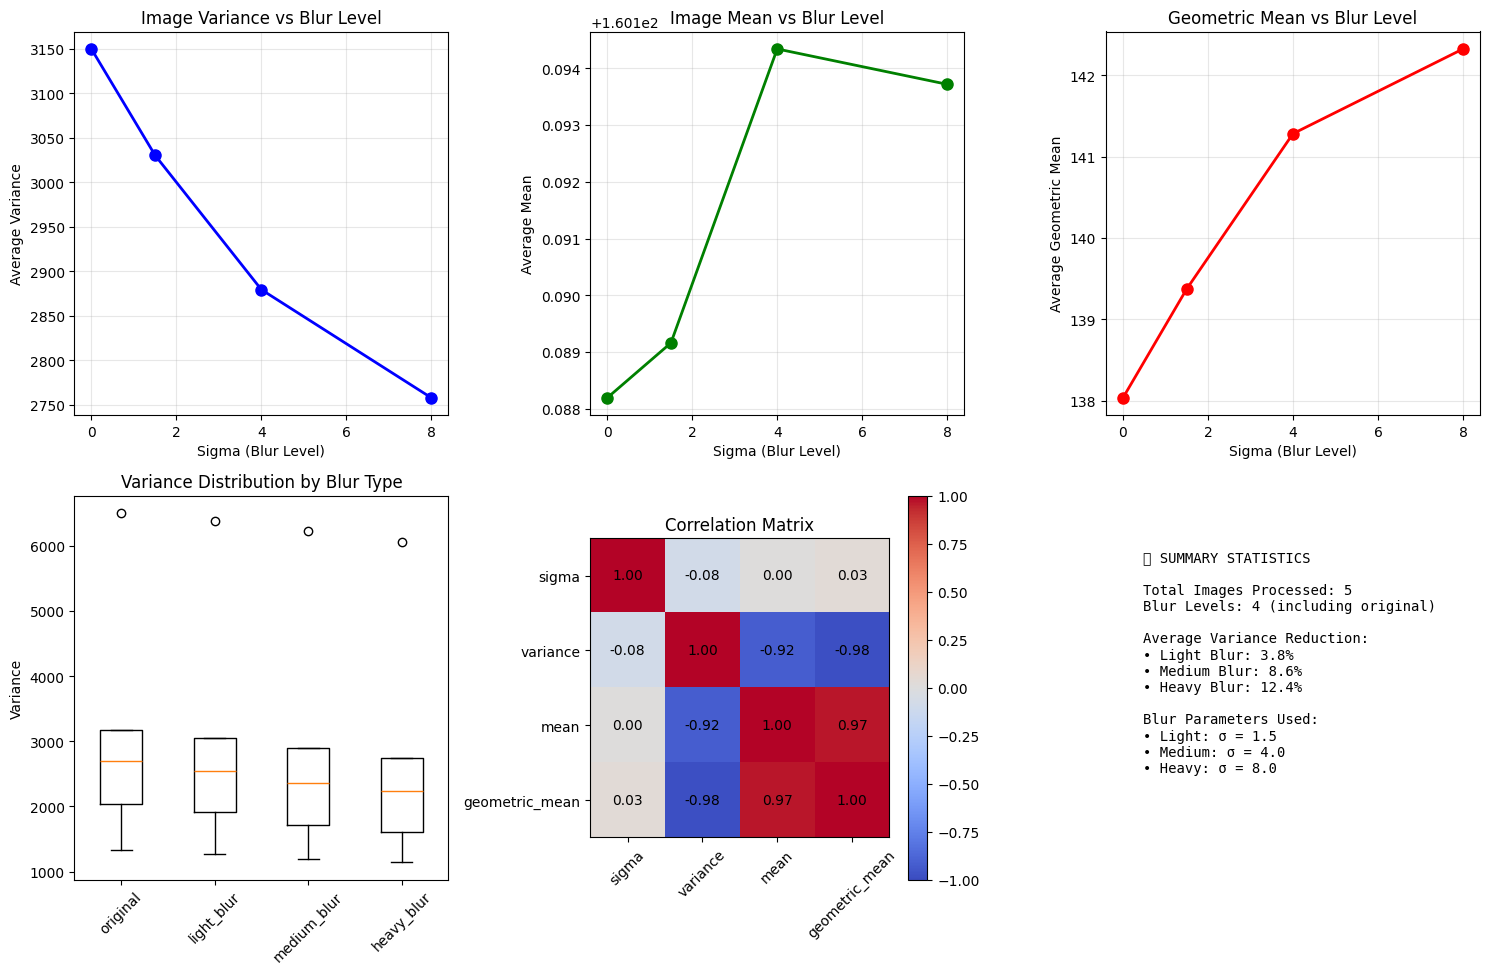

📊 Visualization complete!


In [17]:
# Step 6: Create visualizations
plt.figure(figsize=(15, 10))

# Plot 1: Variance vs Blur Level
plt.subplot(2, 3, 1)
variance_by_blur = df_summary.groupby('sigma')['variance'].mean()
plt.plot(variance_by_blur.index, variance_by_blur.values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Sigma (Blur Level)')
plt.ylabel('Average Variance')
plt.title('Image Variance vs Blur Level')
plt.grid(True, alpha=0.3)

# Plot 2: Mean vs Blur Level  
plt.subplot(2, 3, 2)
mean_by_blur = df_summary.groupby('sigma')['mean'].mean()
plt.plot(mean_by_blur.index, mean_by_blur.values, 'go-', linewidth=2, markersize=8)
plt.xlabel('Sigma (Blur Level)')
plt.ylabel('Average Mean')
plt.title('Image Mean vs Blur Level')
plt.grid(True, alpha=0.3)

# Plot 3: Geometric Mean vs Blur Level
plt.subplot(2, 3, 3)
gm_by_blur = df_summary.groupby('sigma')['geometric_mean'].mean()
plt.plot(gm_by_blur.index, gm_by_blur.values, 'ro-', linewidth=2, markersize=8)
plt.xlabel('Sigma (Blur Level)')
plt.ylabel('Average Geometric Mean')
plt.title('Geometric Mean vs Blur Level')
plt.grid(True, alpha=0.3)

# Plot 4: Box plot of variance by blur type
plt.subplot(2, 3, 4)
blur_order = ['original', 'light_blur', 'medium_blur', 'heavy_blur']
df_ordered = df_summary.set_index('blur_type').loc[blur_order].reset_index()
plt.boxplot([df_ordered[df_ordered['blur_type']==bt]['variance'].values for bt in blur_order], 
            labels=blur_order)
plt.ylabel('Variance')
plt.title('Variance Distribution by Blur Type')
plt.xticks(rotation=45)

# Plot 5: Correlation heatmap
plt.subplot(2, 3, 5)
corr_data = df_summary[['sigma', 'variance', 'mean', 'geometric_mean']].corr()
im = plt.imshow(corr_data, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(corr_data.columns)), corr_data.columns, rotation=45)
plt.yticks(range(len(corr_data.columns)), corr_data.columns)
plt.title('Correlation Matrix')

# Add correlation values
for i in range(len(corr_data.columns)):
    for j in range(len(corr_data.columns)):
        plt.text(j, i, f'{corr_data.iloc[i,j]:.2f}', ha='center', va='center')

# Plot 6: Summary statistics
plt.subplot(2, 3, 6)
plt.axis('off')
summary_text = f"""
📊 SUMMARY STATISTICS

Total Images Processed: {len(image_files)}
Blur Levels: {len(blur_configs) + 1} (including original)

Average Variance Reduction:
• Light Blur: {(variance_by_blur.iloc[0] - variance_by_blur.iloc[1])/variance_by_blur.iloc[0]*100:.1f}%
• Medium Blur: {(variance_by_blur.iloc[0] - variance_by_blur.iloc[2])/variance_by_blur.iloc[0]*100:.1f}%
• Heavy Blur: {(variance_by_blur.iloc[0] - variance_by_blur.iloc[3])/variance_by_blur.iloc[0]*100:.1f}%

Blur Parameters Used:
• Light: σ = {blur_configs['light_blur']['sigma']}
• Medium: σ = {blur_configs['medium_blur']['sigma']}  
• Heavy: σ = {blur_configs['heavy_blur']['sigma']}
"""
plt.text(0.1, 0.9, summary_text, transform=plt.gca().transAxes, 
         verticalalignment='top', fontsize=10, fontfamily='monospace')

plt.tight_layout()
plt.show()

print("📊 Visualization complete!")


In [19]:
# Step 7: Prepare for CRAFT integration
def verify_folder_structure():
    """Verify all folders and count images"""
    print("🔍 Verifying folder structure and image counts:")
    print("=" * 60)
    
    total_images = 0
    for folder_name, folder_path in folders.items():
        images_in_folder = list(folder_path.glob("*.png"))
        total_images += len(images_in_folder)
        print(f"📁 {folder_name:12}: {len(images_in_folder)} images")
        
        # Show sample filenames
        if images_in_folder:
            print(f"   Sample: {images_in_folder[0].name}")
    
    print(f"\n✅ Total images across all folders: {total_images}")
    print(f"📋 Expected total: {len(image_files) * 4} (5 images × 4 variants)")
    
    return total_images == len(image_files) * 4

# Verify everything is ready
is_ready = verify_folder_structure()

if is_ready:
    print(f"\n🎉 SUCCESS! All {len(image_files)} images have been processed into 4 variants each.")
    print("\n📂 Folder structure created:")
    for folder_name, folder_path in folders.items():
        print(f"   • {folder_path}")
    
    print(f"\n📊 Quality metrics calculated and visualized")
    print(f"✅ Ready for CRAFT text detection processing!")
else:
    print("\n❌ ERROR: Missing images detected. Please check the processing above.")


🔍 Verifying folder structure and image counts:
📁 original    : 5 images
   Sample: 01_10021040891039611111693747018_page_1.png
📁 light_blur  : 5 images
   Sample: 01_10021040891039611111693747018_page_1.png
📁 medium_blur : 5 images
   Sample: 01_10021040891039611111693747018_page_1.png
📁 heavy_blur  : 5 images
   Sample: 01_10021040891039611111693747018_page_1.png

✅ Total images across all folders: 20
📋 Expected total: 20 (5 images × 4 variants)

🎉 SUCCESS! All 5 images have been processed into 4 variants each.

📂 Folder structure created:
   • /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft/blurred_images/original
   • /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft/blurred_images/light_blur
   • /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subject

# 🔍 Understanding Gaussian Filter - Deep Dive

## What is a Gaussian Filter?

A **Gaussian filter** is a type of image smoothing filter that uses a **Gaussian (bell-curve) distribution** to blur images. It's one of the most popular blur techniques because it produces natural-looking blur without artifacts.

## Key Concepts:

### 1. **Gaussian Distribution (Bell Curve)**
- The filter uses a 2D Gaussian function: `G(x,y) = (1/(2πσ²)) * e^(-(x²+y²)/(2σ²))`
- **σ (sigma)** controls the "width" of the bell curve σ (sigma) = standard deviation (controls blur strength)
- **x,y = distance from center pixel

- Smaller σ = narrower bell curve = less blur

### 2. **Convolution Process**
- The filter creates a **kernel matrix** based on Gaussian values
- This kernel is "convolved" with every pixel in the image
- Each pixel's new value = weighted average of neighboring pixels

### 3. **Kernel Size**
- Must be **odd** (so there's a center pixel)
- Rule of thumb: `kernel_size ≈ 6 × σ + 1`
- Larger kernels = more neighbors considered = smoother blur
σ = 0 (Original):
Kernel = [[0,0,1,0,0]] (impulse)
No change to image
σ = 1.5 (Light Blur):
Small 5x5 or 7x7 kernel # All values sum to 1.0 (normalization) in kernel
Slight smoothing, preserves edges
σ = 4.0 (Medium Blur):
Larger 15x15 or 25x25 kernel # All values sum to 1.0 (normalization) in kernel
Noticeable smoothing, some detail loss
σ = 8.0 (Heavy Blur):
Very large 49x49 kernel # All values sum to 1.0 (normalization) in kernel 
Heavy smoothing, significant detail loss
# Create coordinate matrices
x_coords = [[-2, -1,  0,  1,  2],
            [-2, -1,  0,  1,  2], 
            [-2, -1,  0,  1,  2],
            [-2, -1,  0,  1,  2],
            [-2, -1,  0,  1,  2]]

y_coords = [[-2, -2, -2, -2, -2],
            [-1, -1, -1, -1, -1],
            [ 0,  0,  0,  0,  0],
            [ 1,  1,  1,  1,  1], 
            [ 2,  2,  2,  2,  2]]

## use craft on those folders

In [21]:
# Simple pip install from requirements.txt
import os

# Change to the directory with requirements.txt
os.chdir("/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft")

# Install requirements
os.system("pip install -r requirements.txt")

print("📦 Requirements installation completed!")

📦 Requirements installation completed!


In [22]:
import sys
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import torch
import time

# Add src to path
sys.path.append('/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft/src')

# Import components directly (bypassing inference.py relative imports)
from craft_text_detector import load_craftnet_model
from craft_helper import process_image_and_detect_text

print("🔄 Loading CRAFT model directly...")
start_time = time.time()
craft_net = load_craftnet_model(cuda=torch.cuda.is_available())
load_time = time.time() - start_time
print(f"✅ CRAFT model loaded in {load_time:.2f} seconds")

# Set up paths
base_path = Path("/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft")
blurred_images_path = base_path / "blurred_images"

# Define categories and sigma values
blur_categories = ['original', 'light_blur', 'medium_blur', 'heavy_blur']
sigma_values = {'original': 0, 'light_blur': 1.5, 'medium_blur': 4.0, 'heavy_blur': 8.0}

def process_image_with_craft(image, text_threshold=0.1, low_text=0.1, link_threshold=0.1, long_size=720):
    """
    Process image using the same logic as your inference.py
    """
    try:
        start_time = time.time()
        
        # Use your craft_helper function directly
        boxes, confs = process_image_and_detect_text(
            image=image,
            model=craft_net,
            text_threshold=text_threshold,
            link_threshold=link_threshold,
            low_text=low_text,
            long_size=long_size,
        )
        
        processing_time = time.time() - start_time
        
        # Format response like your inference.py
        response = {
            "image_source": "local_image",
            "text_regions": [
                {"confidence": conf, "bbox": box.tolist()}
                for box, conf in zip(boxes, confs)
            ],
        }
        
        return {
            "status": 200,
            "model_response": response,
            "processing_time": processing_time
        }
        
    except Exception as e:
        return {"error": str(e), "status": "error"}

print("🚀 Processing all blurred images...")
print("=" * 60)

results = []

for category in blur_categories:
    category_path = blurred_images_path / category
    if not category_path.exists():
        print(f"⚠️  Warning: {category_path} does not exist")
        continue
        
    image_files = list(category_path.glob("*.png"))
    print(f"\n📁 Processing {category} ({len(image_files)} images)...")
    
    for i, img_path in enumerate(image_files, 1):
        print(f"  [{i}/{len(image_files)}] {img_path.name}...", end=" ")
        
        # Load image
        image = cv2.imread(str(img_path))
        if image is None:
            print("❌ Failed to load")
            continue
        
        # Process with CRAFT
        result = process_image_with_craft(image)
        
        if result["status"] == 200:
            response = result["model_response"]
            
            # Calculate image quality metrics
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            
            # Store results
            analysis_result = {
                'image_name': img_path.name,
                'blur_category': category,
                'sigma': sigma_values[category],
                'image_path': str(img_path),
                'image_variance': float(np.var(gray)),
                'image_mean': float(np.mean(gray)),
                'num_detections': len(response['text_regions']),
                'avg_confidence': np.mean([region['confidence'] for region in response['text_regions']]) if response['text_regions'] else 0.0,
                'max_confidence': max([region['confidence'] for region in response['text_regions']]) if response['text_regions'] else 0.0,
                'processing_time': result['processing_time'],
                'craft_response': response
            }
            
            results.append(analysis_result)
            print(f"✅ {analysis_result['num_detections']} detections, conf: {analysis_result['avg_confidence']:.3f}")
            
        else:
            print(f"❌ {result.get('error', 'Unknown error')}")

print(f"\n🎉 Processed {len(results)} images!")

# Create results DataFrame and analysis
if results:
    df = pd.DataFrame(results)
    print("\n📊 Results Summary:")
    summary_cols = ['image_name', 'blur_category', 'sigma', 'num_detections', 'avg_confidence', 'image_variance']
    print(df[summary_cols].round(3))
    
    # Calculate correlations
    print(f"\n🔍 Key Correlations:")
    if len(df) > 1:
        corr_sigma_detections = df['sigma'].corr(df['num_detections'])
        corr_sigma_confidence = df['sigma'].corr(df['avg_confidence'])
        corr_variance_detections = df['image_variance'].corr(df['num_detections'])
        
        print(f"  • Blur Level (σ) ↔ Detections:    {corr_sigma_detections:.3f}")
        print(f"  • Blur Level (σ) ↔ Confidence:    {corr_sigma_confidence:.3f}")
        print(f"  • Image Variance ↔ Detections:    {corr_variance_detections:.3f}")
    
    # Performance by category
    print(f"\n🏆 Performance by Blur Level:")
    perf_summary = df.groupby('blur_category').agg({
        'num_detections': 'mean',
        'avg_confidence': 'mean'
    }).round(3)
    
    for category in blur_categories:
        if category in perf_summary.index:
            row = perf_summary.loc[category]
            print(f"  • {category:12}: {row['num_detections']:5.1f} detections, {row['avg_confidence']:.3f} confidence")
    
    # Save results
    output_file = base_path / "craft_blur_analysis.csv"
    df.to_csv(output_file, index=False)
    print(f"\n💾 Results saved to: {output_file}")
    
else:
    print("❌ No results to display")

print("\n✨ Analysis complete!")

🔄 Loading CRAFT model directly...


/opt/anaconda3/envs/Layout_env/lib/python3.9/site-packages/torchvision/models/_utils.py:252: UserWarning: Accessing the model URLs via the internal dictionary of the module is deprecated since 0.13 and may be removed in the future. Please access them via the appropriate Weights Enum instead.
  warnings.warn(
/opt/anaconda3/envs/Layout_env/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/Layout_env/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ CRAFT model loaded in 1.89 seconds
🚀 Processing all blurred images...

📁 Processing original (5 images)...
  [1/5] 01_10021040891039611111693747018_page_1.png... ✅ 76 detections, conf: 0.146
  [2/5] 11_100210067043036921111705241030_page_3.png... ✅ 49 detections, conf: 0.159
  [3/5] 05_10021030401065351171694351729_page_11.png... ✅ 39 detections, conf: 0.155
  [4/5] 07_100212788145098831111705212250_page_5.png... ✅ 86 detections, conf: 0.154
  [5/5] 02_10021039271083421101694954824_page_2.png... ✅ 51 detections, conf: 0.142

📁 Processing light_blur (5 images)...
  [1/5] 01_10021040891039611111693747018_page_1.png... ✅ 73 detections, conf: 0.147
  [2/5] 11_100210067043036921111705241030_page_3.png... ✅ 46 detections, conf: 0.159
  [3/5] 05_10021030401065351171694351729_page_11.png... ✅ 37 detections, conf: 0.158
  [4/5] 07_100212788145098831111705212250_page_5.png... ✅ 83 detections, conf: 0.153
  [5/5] 02_10021039271083421101694954824_page_2.png... ✅ 54 detections, conf: 0.144

📁 Pro

In [1]:
import pandas as pd
from pathlib import Path

# Read the main CSV file
base_path = Path("/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft")
main_csv = base_path / "craft_blur_analysis.csv"

# Load the data
df = pd.read_csv(main_csv)

print("📊 Splitting data into separate CSV files...")
print("=" * 50)

# Define the blur categories
blur_categories = ['original', 'light_blur', 'medium_blur', 'heavy_blur']

# Create separate CSV for each category
for category in blur_categories:
    # Filter data for this category
    category_data = df[df['blur_category'] == category].copy()
    
    if len(category_data) > 0:
        # Create filename
        output_file = base_path / f"craft_{category}_analysis.csv"
        
        # Save to CSV
        category_data.to_csv(output_file, index=False)
        
        print(f"✅ {category:12}: {len(category_data)} images → {output_file.name}")
        print(f"   Avg detections: {category_data['num_detections'].mean():.1f}")
        print(f"   Avg confidence: {category_data['avg_confidence'].mean():.3f}")
        print(f"   Avg variance:   {category_data['image_variance'].mean():.1f}")
        print()
    else:
        print(f"❌ {category}: No data found")

print("🎉 Data successfully split into 4 separate CSV files!")

# Verify files were created
print("\n📁 Created files:")
for category in blur_categories:
    file_path = base_path / f"craft_{category}_analysis.csv"
    if file_path.exists():
        print(f"  ✅ {file_path.name}")
    else:
        print(f"  ❌ {file_path.name} - not created")

📊 Splitting data into separate CSV files...
✅ original    : 5 images → craft_original_analysis.csv
   Avg detections: 74.0
   Avg confidence: 0.205
   Avg variance:   3150.0

✅ light_blur  : 5 images → craft_light_blur_analysis.csv
   Avg detections: 74.6
   Avg confidence: 0.205
   Avg variance:   3030.3

✅ medium_blur : 5 images → craft_medium_blur_analysis.csv
   Avg detections: 60.2
   Avg confidence: 0.211
   Avg variance:   2879.5

✅ heavy_blur  : 5 images → craft_heavy_blur_analysis.csv
   Avg detections: 16.8
   Avg confidence: 0.203
   Avg variance:   2757.9

🎉 Data successfully split into 4 separate CSV files!

📁 Created files:
  ✅ craft_original_analysis.csv
  ✅ craft_light_blur_analysis.csv
  ✅ craft_medium_blur_analysis.csv
  ✅ craft_heavy_blur_analysis.csv


In [4]:
import pandas as pd
import numpy as np
from pathlib import Path

# Set up paths
base_path = Path("/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft")

# Define the CSV files
csv_files = {
    'original': 'craft_original_analysis.csv',
    'light_blur': 'craft_light_blur_analysis.csv', 
    'medium_blur': 'craft_medium_blur_analysis.csv',
    'heavy_blur': 'craft_heavy_blur_analysis.csv'
}

print("📊 Complete Statistics for Each Blur Level")
print("=" * 80)

# Store results for comparison
summary_results = []

for category, filename in csv_files.items():
    file_path = base_path / filename
    
    if file_path.exists():
        # Load the CSV
        df = pd.read_csv(file_path)
        
        # Extract confidence scores and detection counts
        confidence_scores = df['avg_confidence'].values
        detection_counts = df['num_detections'].values
        
        # Calculate CONFIDENCE statistics
        mean_confidence = np.mean(confidence_scores)
        variance_confidence = np.var(confidence_scores)
        std_confidence = np.std(confidence_scores)
        product_confidence = np.prod(confidence_scores)
        
        # Calculate DETECTION statistics
        total_detections = np.sum(detection_counts)  # SUM of all detections
        mean_detections_per_image = np.mean(detection_counts)
        
        # Get other info
        sigma = df['sigma'].iloc[0]
        num_images = len(df)
        
        print(f"\n🔹 {category.upper()} (σ = {sigma})")
        print(f"   Number of images:           {num_images}")
        print(f"   TOTAL detections:           {total_detections}")
        print(f"   Avg detections per image:   {mean_detections_per_image:.1f}")
        print(f"   Mean confidence:            {mean_confidence:.6f}")
        print(f"   Variance confidence:        {variance_confidence:.6f}")
        print(f"   Std Dev confidence:         {std_confidence:.6f}")
        print(f"   Product confidence:         {product_confidence:.2e}")
        
        # Store for summary
        summary_results.append({
            'blur_category': category,
            'sigma': sigma,
            'num_images': num_images,
            'total_detections': total_detections,
            'mean_confidence': mean_confidence,
            'variance_confidence': variance_confidence,
            'std_confidence': std_confidence,
            'product_confidence': product_confidence
        })
        
    else:
        print(f"❌ {filename} not found")

# Create summary DataFrame
summary_df = pd.DataFrame(summary_results)

print(f"\n\n📈 SUMMARY COMPARISON TABLE")
print("=" * 80)
print(summary_df.round(6))

# Calculate detection degradation
if len(summary_df) > 0:
    original_row = summary_df[summary_df['blur_category'] == 'original']
    if len(original_row) > 0:
        original_total = original_row['total_detections'].iloc[0]
        original_mean_conf = original_row['mean_confidence'].iloc[0]
        
        print(f"\n🔍 PERFORMANCE DEGRADATION FROM ORIGINAL:")
        print("=" * 60)
        print(f"{'Category':<12} {'Sigma':<6} {'Total Det.':<10} {'Det. Change':<12} {'Conf. Change':<12}")
        print("-" * 60)
        
        for _, row in summary_df.iterrows():
            det_change = ((row['total_detections'] - original_total) / original_total) * 100
            conf_change = ((row['mean_confidence'] - original_mean_conf) / original_mean_conf) * 100
            
            print(f"{row['blur_category']:<12} {row['sigma']:<6.1f} {row['total_detections']:<10} "
                  f"{det_change:+6.1f}%     {conf_change:+6.1f}%")

# Save detailed summary
output_file = base_path / "complete_statistics_summary.csv"
summary_df.to_csv(output_file, index=False)
print(f"\n💾 Complete summary saved to: {output_file.name}")

# Quick comparison table
print(f"\n\n🎯 QUICK COMPARISON:")
print("=" * 50)
for _, row in summary_df.iterrows():
    print(f"{row['blur_category']:12} (σ={row['sigma']:3.1f}): "
          f"{row['total_detections']:3d} total detections, "
          f"{row['mean_confidence']:.3f} avg confidence")

📊 Complete Statistics for Each Blur Level

🔹 ORIGINAL (σ = 0.0)
   Number of images:           5
   TOTAL detections:           370
   Avg detections per image:   74.0
   Mean confidence:            0.205171
   Variance confidence:        0.000024
   Std Dev confidence:         0.004945
   Product confidence:         3.63e-04

🔹 LIGHT_BLUR (σ = 1.5)
   Number of images:           5
   TOTAL detections:           373
   Avg detections per image:   74.6
   Mean confidence:            0.204639
   Variance confidence:        0.000042
   Std Dev confidence:         0.006448
   Product confidence:         3.58e-04

🔹 MEDIUM_BLUR (σ = 4.0)
   Number of images:           5
   TOTAL detections:           301
   Avg detections per image:   60.2
   Mean confidence:            0.211272
   Variance confidence:        0.000056
   Std Dev confidence:         0.007516
   Product confidence:         4.20e-04

🔹 HEAVY_BLUR (σ = 8.0)
   Number of images:           5
   TOTAL detections:           84
   A

## Summary analytics
- mean
1. Surprising Performance Gain
Light blur (σ=1.5) slightly outperforms original images
+3 additional detections with maintained confidence
Implication: Slight smoothing may reduce noise and help CRAFT

2. Quality vs Quantity Trade-off
Medium blur: Fewer detections but higher confidence (0.211)
Heavy blur: Massive detection loss but confidence remains stable
CRAFT becomes more selective as blur increases

✅ SAFE ZONE (σ ≤ 1.5):    Minimal to beneficial impact

3. variance - as blur increases vairance increases MORE UNPREDICTABLE and INCONSISTENT performance more Wide spread-Heavy blur creates a system where CRAFT might work perfectly on one image and fail completely on the next

4. product_confidence
Higher product = Better overall batch performance,How well the system performs as a whole Medium Blur > Original > Light Blur > Heavy Blur




### for rotation images

In [5]:
import cv2
import numpy as np
from pathlib import Path
import os

# Set up paths
base_path = Path("/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft")
input_path = base_path / "images"  # Your upright images
output_base = base_path / "rotated_images"

print("🔄 Image Rotation Setup")
print("=" * 50)
print(f"📁 Input folder: {input_path}")
print(f"📁 Output folder: {output_base}")

# Create output folder structure
rotation_folders = {
    'upright': output_base / 'upright',           # 0° (original)
    'rotate_90': output_base / 'rotate_90',       # 90° anticlockwise  
    'rotate_180': output_base / 'rotate_180'      # 180° anticlockwise (upside down)
}

# Create directories
for folder_name, folder_path in rotation_folders.items():
    folder_path.mkdir(parents=True, exist_ok=True)
    print(f"✅ Created: {folder_path}")

def rotate_image(image, angle):
    """
    Rotate image by specified angle (anticlockwise)
    
    Args:
        image: Input image array
        angle: Rotation angle in degrees (positive = anticlockwise)
    
    Returns:
        Rotated image
    """
    height, width = image.shape[:2]
    
    if angle == 90:
        # 90° anticlockwise = transpose + flip horizontally
        rotated = cv2.transpose(image)
        rotated = cv2.flip(rotated, 0)
    elif angle == 180:
        # 180° = flip both horizontally and vertically
        rotated = cv2.flip(image, -1)
    elif angle == 270:
        # 270° anticlockwise = transpose + flip vertically
        rotated = cv2.transpose(image)
        rotated = cv2.flip(rotated, 1)
    else:
        # For other angles, use rotation matrix
        center = (width // 2, height // 2)
        rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv2.warpAffine(image, rotation_matrix, (width, height))
    
    return rotated

# Get all PNG images from input folder
image_files = list(input_path.glob("*.png"))
print(f"\n🖼️  Found {len(image_files)} images to rotate:")
for img_file in image_files:
    print(f"  • {img_file.name}")

print(f"\n🔄 Processing rotations...")
print("=" * 60)

# Process each image
for img_file in image_files:
    print(f"\n📷 Processing: {img_file.name}")
    
    # Load original image
    image = cv2.imread(str(img_file))
    if image is None:
        print(f"  ❌ Failed to load {img_file.name}")
        continue
    
    # 1. Copy original (upright) image
    upright_path = rotation_folders['upright'] / img_file.name
    cv2.imwrite(str(upright_path), image)
    print(f"  ✅ Upright (0°): {upright_path.name}")
    
    # 2. Create 90° anticlockwise rotation
    rotated_90 = rotate_image(image, 90)
    rotate_90_path = rotation_folders['rotate_90'] / img_file.name
    cv2.imwrite(str(rotate_90_path), rotated_90)
    print(f"  ✅ 90° anticlockwise: {rotate_90_path.name}")
    
    # 3. Create 180° rotation (upside down)
    rotated_180 = rotate_image(image, 180)
    rotate_180_path = rotation_folders['rotate_180'] / img_file.name
    cv2.imwrite(str(rotate_180_path), rotated_180)
    print(f"  ✅ 180° anticlockwise: {rotate_180_path.name}")

print(f"\n🎉 Rotation Complete!")
print("=" * 50)

# Verify results
print(f"\n📊 Verification:")
total_created = 0
for folder_name, folder_path in rotation_folders.items():
    created_images = list(folder_path.glob("*.png"))
    total_created += len(created_images)
    print(f"  📁 {folder_name:12}: {len(created_images)} images")

expected_total = len(image_files) * 3  # 3 rotations per image
print(f"\n✅ Total images created: {total_created}")
print(f"📋 Expected total: {expected_total}")

if total_created == expected_total:
    print("🎉 SUCCESS! All rotations created successfully.")
    
    print(f"\n📂 Folder structure created:")
    for folder_name, folder_path in rotation_folders.items():
        print(f"   • {folder_path}")
        
    print(f"\n🚀 Ready for CRAFT rotation analysis!")
    print(f"   • Original images: {len(image_files)}")
    print(f"   • Total rotated images: {total_created}")
    print(f"   • Rotation angles: 0°, 90°, 180°")
    
else:
    print("⚠️  Warning: Some images may not have been created correctly.")

# Show image dimensions for verification
sample_image = image_files[0] if image_files else None
if sample_image:
    original = cv2.imread(str(sample_image))
    rotated_90 = cv2.imread(str(rotation_folders['rotate_90'] / sample_image.name))
    
    print(f"\n📐 Dimension Check (using {sample_image.name}):")
    print(f"   Original (0°):   {original.shape[1]}×{original.shape[0]}")
    print(f"   Rotated (90°):   {rotated_90.shape[1]}×{rotated_90.shape[0]}")
    print(f"   Note: 90° rotation swaps width/height as expected")

🔄 Image Rotation Setup
📁 Input folder: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft/images
📁 Output folder: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft/rotated_images
✅ Created: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft/rotated_images/upright
✅ Created: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft/rotated_images/rotate_90
✅ Created: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft/rotated_images/rotate_180

🖼️  Found 5 im

In [10]:
import sys
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import time
import torch

# Add src to path for CRAFT
sys.path.append('/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft/src')

# Import CRAFT components
from craft_text_detector import load_craftnet_model
from craft_helper import process_image_and_detect_text

print("🔄 Loading CRAFT model...")
start_time = time.time()
craft_net = load_craftnet_model(cuda=torch.cuda.is_available())
load_time = time.time() - start_time
print(f"✅ CRAFT model loaded in {load_time:.2f} seconds")

# Set up paths
base_path = Path("/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft")
rotated_images_path = base_path / "rotated_images"

# Define rotation categories
rotation_categories = ['upright', 'rotate_90', 'rotate_180']
rotation_angles = {'upright': 0, 'rotate_90': 90, 'rotate_180': 180}

def process_image_with_craft(image, text_threshold=0.3, low_text=0.2, link_threshold=0.1, long_size=720):
    """
    Process image using CRAFT text detection
    """
    try:
        start_time = time.time()
        
        # Use CRAFT helper function
        boxes, confs = process_image_and_detect_text(
            image=image,
            model=craft_net,
            text_threshold=text_threshold,
            link_threshold=link_threshold,
            low_text=low_text,
            long_size=long_size,
        )
        
        processing_time = time.time() - start_time
        
        # Format response
        response = {
            "image_source": "local_image",
            "text_regions": [
                {"confidence": conf, "bbox": box.tolist()}
                for box, conf in zip(boxes, confs)
            ],
        }
        
        return {
            "status": 200,
            "model_response": response,
            "processing_time": processing_time
        }
        
    except Exception as e:
        return {"error": str(e), "status": "error"}

print("🚀 Processing all rotation sets through CRAFT...")
print("=" * 80)

# Store all results for comparison
all_results = {}

# Process each rotation category
for category in rotation_categories:
    category_path = rotated_images_path / category
    
    if not category_path.exists():
        print(f"⚠️  Warning: {category_path} does not exist")
        continue
        
    image_files = list(category_path.glob("*.png"))
    print(f"\n📁 Processing {category} ({len(image_files)} images)...")
    print(f"   Rotation angle: {rotation_angles[category]}°")
    
    category_results = []
    
    for i, img_path in enumerate(image_files, 1):
        print(f"  [{i}/{len(image_files)}] {img_path.name}...", end=" ")
        
        # Load image
        image = cv2.imread(str(img_path))
        if image is None:
            print("❌ Failed to load")
            continue
        
        # Process with CRAFT
        result = process_image_with_craft(image)
        
        if result["status"] == 200:
            response = result["model_response"]
            
            # Calculate image quality metrics (grayscale analysis)
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
            
            # ✨ ENHANCED: Calculate ALL statistical metrics
            confidence_scores = [region['confidence'] for region in response['text_regions']]
            
            # Store results with ENHANCED metrics
            analysis_result = {
                'image_name': img_path.name,
                'rotation_category': category,
                'rotation_angle': rotation_angles[category],
                'image_path': str(img_path),
                
                # 📊 IMAGE Quality Metrics
                'image_variance': float(np.var(gray)),
                'image_mean': float(np.mean(gray)),
                'image_std': float(np.std(gray)),
                
                # 🎯 CRAFT Detection Metrics
                'num_detections': len(response['text_regions']),
                
                # 📈 CONFIDENCE Statistics (what you wanted!)
                'avg_confidence': np.mean(confidence_scores) if confidence_scores else 0.0,
                'max_confidence': max(confidence_scores) if confidence_scores else 0.0,
                'min_confidence': min(confidence_scores) if confidence_scores else 0.0,
                'variance_confidence': float(np.var(confidence_scores)) if len(confidence_scores) > 1 else 0.0,  # ← VARIANCE
                'std_confidence': float(np.std(confidence_scores)) if confidence_scores else 0.0,              # ← STANDARD DEVIATION
                'product_confidence': float(np.prod(confidence_scores)) if confidence_scores else 0.0,         # ← PRODUCT
                
                # ⏱️ Performance Metrics
                'processing_time': result['processing_time'],
                'craft_response': response
            }
            
            category_results.append(analysis_result)
            print(f"✅ {analysis_result['num_detections']} det, conf: {analysis_result['avg_confidence']:.3f}, var: {analysis_result['variance_confidence']:.6f}")
            
        else:
            print(f"❌ {result.get('error', 'Unknown error')}")
    
    # Store results for this category
    all_results[category] = category_results
    
    print(f"   📊 {category} summary: {len(category_results)} images processed")

print(f"\n🎉 All rotation processing complete!")

# Create individual CSV files for each rotation
print(f"\n📄 Creating individual CSV files with ENHANCED metrics...")
print("=" * 70)

individual_summaries = []

for category, results in all_results.items():
    if results:
        # Create DataFrame for this rotation
        df = pd.DataFrame(results)
        
        # Save individual CSV (now with variance, std, product!)
        csv_filename = f"craft_{category}_analysis.csv"
        output_file = base_path / csv_filename
        df.to_csv(output_file, index=False)
        
        # ✨ ENHANCED: Calculate summary statistics with ALL metrics
        total_detections = df['num_detections'].sum()
        avg_detections_per_image = df['num_detections'].mean()
        
        # Confidence statistics (aggregated across all images in category)
        mean_confidence = df['avg_confidence'].mean()
        variance_confidence = df['avg_confidence'].var()        # ← VARIANCE across images
        std_confidence = df['avg_confidence'].std()             # ← STD DEV across images  
        product_confidence = df['avg_confidence'].prod()        # ← PRODUCT across images
        
        # Additional detailed stats
        mean_variance_within = df['variance_confidence'].mean()  # Average within-image variance
        mean_std_within = df['std_confidence'].mean()           # Average within-image std
        mean_product_within = df['product_confidence'].mean()   # Average within-image product
        
        summary = {
            'rotation_category': category,
            'rotation_angle': rotation_angles[category],
            'num_images': len(results),
            'total_detections': total_detections,
            'avg_detections_per_image': avg_detections_per_image,
            
            # 📊 CONFIDENCE Aggregated Statistics (across images)
            'mean_confidence': mean_confidence,
            'variance_confidence': variance_confidence,    # ← What you wanted!
            'std_confidence': std_confidence,              # ← What you wanted!
            'product_confidence': product_confidence,      # ← What you wanted!
            
            # 📈 WITHIN-IMAGE Statistics (averaged)
            'avg_variance_within_images': mean_variance_within,
            'avg_std_within_images': mean_std_within,
            'avg_product_within_images': mean_product_within
        }
        
        individual_summaries.append(summary)
        
        print(f"✅ {csv_filename:25} | {len(results):2d} imgs | {total_detections:3d} det | conf: {mean_confidence:.3f} | var: {variance_confidence:.6f} | prod: {product_confidence:.2e}")
    else:
        print(f"❌ {category:25} | No results to save")

# Create ENHANCED combined summary CSV
if individual_summaries:
    summary_df = pd.DataFrame(individual_summaries)
    
    # Save TWO summary files:
    # 1. Basic summary (like before)
    basic_summary_file = base_path / "rotation_statistics_summary.csv"
    basic_cols = ['rotation_category', 'rotation_angle', 'num_images', 'total_detections', 'mean_confidence', 'variance_confidence', 'std_confidence', 'product_confidence']
    summary_df[basic_cols].to_csv(basic_summary_file, index=False)
    
    # 2. COMPLETE summary (with all metrics)
    complete_summary_file = base_path / "complete_rotation_statistics_summary.csv"
    summary_df.to_csv(complete_summary_file, index=False)
    
    print(f"\n📊 ENHANCED ROTATION ANALYSIS SUMMARY:")
    print("=" * 100)
    print("Basic Statistics:")
    print(summary_df[basic_cols].round(6))
    
    print(f"\n📊 DETAILED STATISTICS (Variance, Std, Product):")
    print("=" * 100)
    detail_cols = ['rotation_category', 'variance_confidence', 'std_confidence', 'product_confidence']
    print(summary_df[detail_cols].round(6))
    
    # Calculate performance changes with ENHANCED metrics
    if len(summary_df) > 0:
        upright_row = summary_df[summary_df['rotation_category'] == 'upright']
        if len(upright_row) > 0:
            upright_detections = upright_row['total_detections'].iloc[0]
            upright_confidence = upright_row['mean_confidence'].iloc[0]
            upright_variance = upright_row['variance_confidence'].iloc[0]
            upright_product = upright_row['product_confidence'].iloc[0]
            
            print(f"\n🔍 ENHANCED PERFORMANCE CHANGES FROM UPRIGHT:")
            print("=" * 90)
            print(f"{'Rotation':<12} {'Angle':<6} {'Det.%':<8} {'Conf.%':<8} {'Var.%':<8} {'Prod.%':<8}")
            print("-" * 90)
            
            for _, row in summary_df.iterrows():
                det_change = ((row['total_detections'] - upright_detections) / upright_detections) * 100
                conf_change = ((row['mean_confidence'] - upright_confidence) / upright_confidence) * 100
                
                # Handle division by zero for variance
                if upright_variance > 0:
                    var_change = ((row['variance_confidence'] - upright_variance) / upright_variance) * 100
                else:
                    var_change = 0
                    
                # Handle division by zero for product
                if upright_product > 0:
                    prod_change = ((row['product_confidence'] - upright_product) / upright_product) * 100
                else:
                    prod_change = 0
                
                print(f"{row['rotation_category']:<12} {row['rotation_angle']:<6.0f}° {det_change:+6.1f}% {conf_change:+6.1f}% {var_change:+6.1f}% {prod_change:+6.1f}%")
    
    print(f"\n💾 ENHANCED Files created:")
    print(f"   📄 Individual CSVs: craft_upright_analysis.csv, craft_rotate_90_analysis.csv, craft_rotate_180_analysis.csv")
    print(f"   📊 Basic Summary: rotation_statistics_summary.csv")
    print(f"   📊 COMPLETE Summary: complete_rotation_statistics_summary.csv (with variance, std, product!)")
    
else:
    print("❌ No results to summarize")

print(f"\n✨ ENHANCED rotation analysis complete!")
print(f"📈 Now you have variance, standard deviation, and product confidence metrics!")
print(f"🎯 Ready for advanced statistical analysis!")

🔄 Loading CRAFT model...


/opt/anaconda3/envs/Layout_env/lib/python3.9/site-packages/torchvision/models/_utils.py:252: UserWarning: Accessing the model URLs via the internal dictionary of the module is deprecated since 0.13 and may be removed in the future. Please access them via the appropriate Weights Enum instead.
  warnings.warn(
/opt/anaconda3/envs/Layout_env/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/opt/anaconda3/envs/Layout_env/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ CRAFT model loaded in 1.94 seconds
🚀 Processing all rotation sets through CRAFT...

📁 Processing upright (5 images)...
   Rotation angle: 0°
  [1/5] 01_10021040891039611111693747018_page_1.png... ✅ 74 det, conf: 0.200, var: 0.001108
  [2/5] 11_100210067043036921111705241030_page_3.png... ✅ 75 det, conf: 0.205, var: 0.000887
  [3/5] 05_10021030401065351171694351729_page_11.png... ✅ 81 det, conf: 0.213, var: 0.001072
  [4/5] 07_100212788145098831111705212250_page_5.png... ✅ 90 det, conf: 0.200, var: 0.000802
  [5/5] 02_10021039271083421101694954824_page_2.png... ✅ 50 det, conf: 0.207, var: 0.001051
   📊 upright summary: 5 images processed

📁 Processing rotate_90 (5 images)...
   Rotation angle: 90°
  [1/5] 01_10021040891039611111693747018_page_1.png... ✅ 87 det, conf: 0.199, var: 0.001225
  [2/5] 11_100210067043036921111705241030_page_3.png... ✅ 78 det, conf: 0.189, var: 0.000888
  [3/5] 05_10021030401065351171694351729_page_11.png... ✅ 61 det, conf: 0.202, var: 0.000936
  [4/5] 07_100

In [11]:
import pandas as pd
import numpy as np
from pathlib import Path

# Set up paths
base_path = Path("/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/trial/image_quality_Final_pro_2.5/craft")

# Define the rotation CSV files
rotation_csv_files = {
    'upright': 'craft_upright_analysis.csv',
    'rotate_90': 'craft_rotate_90_analysis.csv', 
    'rotate_180': 'craft_rotate_180_analysis.csv'
}

print("📊 Complete Rotation Statistics Analysis")
print("=" * 80)

# Store results for comparison
summary_results = []

for category, filename in rotation_csv_files.items():
    file_path = base_path / filename
    
    if file_path.exists():
        # Load the CSV
        df = pd.read_csv(file_path)
        
        # Extract confidence scores and detection counts
        confidence_scores = df['avg_confidence'].values
        detection_counts = df['num_detections'].values
        
        # Calculate CONFIDENCE statistics
        mean_confidence = np.mean(confidence_scores)
        variance_confidence = np.var(confidence_scores)
        std_confidence = np.std(confidence_scores)
        product_confidence = np.prod(confidence_scores)
        
        # Calculate DETECTION statistics
        total_detections = np.sum(detection_counts)  # SUM of all detections
        mean_detections_per_image = np.mean(detection_counts)
        
        # Get other info
        rotation_angle = df['rotation_angle'].iloc[0]
        num_images = len(df)
        
        print(f"\n🔹 {category.upper()} ({rotation_angle}°)")
        print(f"   Number of images:           {num_images}")
        print(f"   TOTAL detections:           {total_detections}")
        print(f"   Avg detections per image:   {mean_detections_per_image:.1f}")
        print(f"   Mean confidence:            {mean_confidence:.6f}")
        print(f"   Variance confidence:        {variance_confidence:.6f}")
        print(f"   Std Dev confidence:         {std_confidence:.6f}")
        print(f"   Product confidence:         {product_confidence:.2e}")
        
        # Store for summary
        summary_results.append({
            'rotation_category': category,
            'rotation_angle': rotation_angle,
            'num_images': num_images,
            'total_detections': total_detections,
            'mean_confidence': mean_confidence,
            'variance_confidence': variance_confidence,
            'std_confidence': std_confidence,
            'product_confidence': product_confidence
        })
        
    else:
        print(f"❌ {filename} not found")

# Create summary DataFrame
summary_df = pd.DataFrame(summary_results)

print(f"\n\n📈 COMPLETE ROTATION STATISTICS SUMMARY")
print("=" * 80)
print(summary_df.round(6))

# Calculate performance degradation from upright
if len(summary_df) > 0:
    upright_row = summary_df[summary_df['rotation_category'] == 'upright']
    if len(upright_row) > 0:
        upright_total = upright_row['total_detections'].iloc[0]
        upright_mean_conf = upright_row['mean_confidence'].iloc[0]
        upright_variance = upright_row['variance_confidence'].iloc[0]
        
        print(f"\n🔍 PERFORMANCE DEGRADATION FROM UPRIGHT:")
        print("=" * 70)
        print(f"{'Category':<12} {'Angle':<6} {'Total Det.':<10} {'Det. Change':<12} {'Conf. Change':<12} {'Var. Change':<12}")
        print("-" * 70)
        
        for _, row in summary_df.iterrows():
            det_change = ((row['total_detections'] - upright_total) / upright_total) * 100
            conf_change = ((row['mean_confidence'] - upright_mean_conf) / upright_mean_conf) * 100
            
            if upright_variance > 0:
                var_change = ((row['variance_confidence'] - upright_variance) / upright_variance) * 100
            else:
                var_change = 0
            
            print(f"{row['rotation_category']:<12} {row['rotation_angle']:<6.0f}° {row['total_detections']:<10} "
                  f"{det_change:+6.1f}%     {conf_change:+6.1f}%     {var_change:+6.1f}%")

# Calculate rotation tolerance analysis
print(f"\n🔄 ROTATION TOLERANCE ANALYSIS:")
print("=" * 50)

if len(summary_df) >= 2:
    # Sort by rotation angle for analysis
    df_sorted = summary_df.sort_values('rotation_angle')
    
    print(f"📊 Detection Performance Ranking:")
    for i, (_, row) in enumerate(df_sorted.iterrows(), 1):
        percentage_of_upright = (row['total_detections'] / upright_total) * 100
        print(f"  {i}. {row['rotation_category']:12} ({row['rotation_angle']:3.0f}°): "
              f"{row['total_detections']:3d} detections ({percentage_of_upright:5.1f}% of upright)")
    
    print(f"\n📊 Confidence Performance Ranking:")
    df_conf_sorted = summary_df.sort_values('mean_confidence', ascending=False)
    for i, (_, row) in enumerate(df_conf_sorted.iterrows(), 1):
        conf_ratio = (row['mean_confidence'] / upright_mean_conf) * 100
        print(f"  {i}. {row['rotation_category']:12} ({row['rotation_angle']:3.0f}°): "
              f"{row['mean_confidence']:.3f} confidence ({conf_ratio:5.1f}% of upright)")

# Consistency analysis
print(f"\n📈 CONSISTENCY ANALYSIS:")
print("=" * 40)
df_var_sorted = summary_df.sort_values('variance_confidence')
print(f"Most to Least Consistent (by variance):")
for i, (_, row) in enumerate(df_var_sorted.iterrows(), 1):
    if upright_variance > 0:
        consistency_ratio = row['variance_confidence'] / upright_variance
        consistency_desc = "MORE" if consistency_ratio > 1 else "LESS"
        print(f"  {i}. {row['rotation_category']:12} ({row['rotation_angle']:3.0f}°): "
              f"Variance = {row['variance_confidence']:.6f} ({consistency_ratio:.1f}x {consistency_desc} variable)")
    else:
        print(f"  {i}. {row['rotation_category']:12} ({row['rotation_angle']:3.0f}°): "
              f"Variance = {row['variance_confidence']:.6f}")

# Combined performance analysis
print(f"\n🎯 COMBINED PERFORMANCE INDEX:")
print("=" * 45)
print("(Higher = Better overall performance)")

for _, row in summary_df.iterrows():
    # Weighted performance index: 70% detections + 30% confidence
    det_score = (row['total_detections'] / upright_total) * 0.7
    conf_score = (row['mean_confidence'] / upright_mean_conf) * 0.3
    combined_score = (det_score + conf_score) * 100
    
    print(f"  {row['rotation_category']:12} ({row['rotation_angle']:3.0f}°): "
          f"Performance Index = {combined_score:5.1f}/100")

# Save comprehensive summary
output_file = base_path / "complete_rotation_statistics_summary.csv"
summary_df.to_csv(output_file, index=False)
print(f"\n💾 Complete statistics saved to: {output_file.name}")

# Quick comparison with blur analysis (if available)
blur_summary_file = base_path / "complete_statistics_summary.csv"
if blur_summary_file.exists():
    print(f"\n🔍 QUICK COMPARISON WITH BLUR ANALYSIS:")
    print("=" * 50)
    
    blur_df = pd.read_csv(blur_summary_file)
    
    # Find original/upright performance from both analyses
    rotation_upright = summary_df[summary_df['rotation_category'] == 'upright']
    blur_original = blur_df[blur_df['blur_category'] == 'original']
    
    if len(rotation_upright) > 0 and len(blur_original) > 0:
        rot_detections = rotation_upright['total_detections'].iloc[0]
        blur_detections = blur_original['total_detections'].iloc[0]
        
        rot_confidence = rotation_upright['mean_confidence'].iloc[0]
        blur_confidence = blur_original['mean_confidence'].iloc[0]
        
        print(f"Baseline Performance:")
        print(f"  Rotation Upright: {rot_detections} detections, {rot_confidence:.3f} confidence")
        print(f"  Blur Original:    {blur_detections} detections, {blur_confidence:.3f} confidence")
        
        if abs(rot_detections - blur_detections) > 5:
            print(f"⚠️  Note: Different baseline performance - may be using different image sets")
        else:
            print(f"✅ Similar baselines - good for comparison")

print(f"\n✨ Complete rotation statistics analysis finished!")
print(f"📈 Ready for detailed rotation vs blur comparison!")

📊 Complete Rotation Statistics Analysis

🔹 UPRIGHT (0°)
   Number of images:           5
   TOTAL detections:           370
   Avg detections per image:   74.0
   Mean confidence:            0.205171
   Variance confidence:        0.000024
   Std Dev confidence:         0.004945
   Product confidence:         3.63e-04

🔹 ROTATE_90 (90°)
   Number of images:           5
   TOTAL detections:           357
   Avg detections per image:   71.4
   Mean confidence:            0.200734
   Variance confidence:        0.000043
   Std Dev confidence:         0.006590
   Product confidence:         3.25e-04

🔹 ROTATE_180 (180°)
   Number of images:           5
   TOTAL detections:           372
   Avg detections per image:   74.4
   Mean confidence:            0.198411
   Variance confidence:        0.000018
   Std Dev confidence:         0.004190
   Product confidence:         3.07e-04


📈 COMPLETE ROTATION STATISTICS SUMMARY
  rotation_category  rotation_angle  num_images  total_detections  \
0 